Cargo los datos

In [1]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
import os
from sklearn.neural_network import MLPRegressor

frequency = '1h'
# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")

# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_WEMH.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data

Frecuencia recibida desde papermill: 1h


,BTCUSDT_1h,ETHUSDT_1h,XRPUSDT_1h,BNBUSDT_1h,SOLUSDT_1h,ADAUSDT_1h,TRXUSDT_1h,LINKUSDT_1h,AVAXUSDT_1h
timestamp,,,,,,,,,
2020-09-22 06:00:00,10423.27,342.05,0.23230,23.3510,2.8000,0.08082,0.02508,8.8803,4.8811
2020-09-22 07:00:00,10372.90,336.12,0.22978,22.9993,2.6728,0.07962,0.02474,8.7300,4.9096
2020-09-22 08:00:00,10463.18,342.11,0.23129,23.4484,2.7602,0.08143,0.02493,8.8209,6.8219
2020-09-22 09:00:00,10452.03,340.09,0.23144,23.5538,2.7857,0.08153,0.02483,8.8347,6.2108
2020-09-22 10:00:00,10458.40,341.00,0.23197,23.8488,2.7847,0.08198,0.02492,8.8923,5.4901
...,...,...,...,...,...,...,...,...,...
2024-12-31 20:00:00,93564.04,3346.20,2.10030,702.5100,194.0200,0.84900,0.25510,20.0000,35.8700
2024-12-31 21:00:00,93899.68,3352.75,2.09820,702.8000,193.1600,0.85230,0.25550,20.0800,35.9300
2024-12-31 22:00:00,93488.84,3339.88,2.07880,701.0700,191.1300,0.84430,0.25460,19.9400,35.6500


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [2]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_WEMH.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'IN/OUT Sample'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Representación de los datos

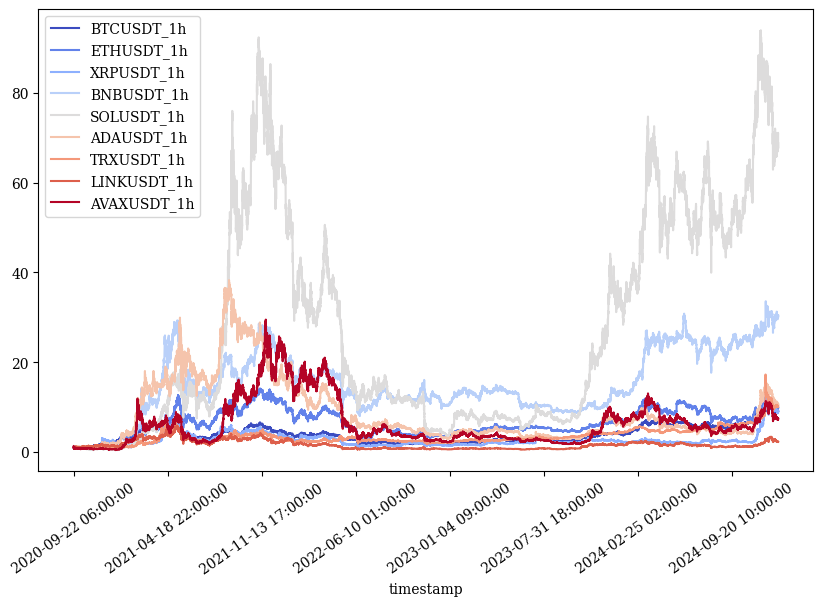

In [ ]:
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
fig, ax = plt.subplots(figsize=(10, 6))
(data / data.iloc[0]).plot(ax=ax, cmap='coolwarm')
ax.set_facecolor('#f7f7f7') 
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.2)
ax.minorticks_on()
ax.tick_params(axis='x', rotation=45)
ax.set_title('Precios de Cierre de las Criptomonedas', fontsize=14)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Precios de Cierre')
plt.tight_layout()
plt.show()


Retardamos los datos para crear los lags de cada instante de tiempo

In [4]:
lags = 7

def add_lags(data, ric, lags):
    cols = []
    df = pd.DataFrame(data[ric])
    for lag in range(1, lags + 1):
        col = 'lag_{}'.format(lag)
        df[col] = df[ric].shift(lag)
        cols.append(col)
    return df, cols

dfs = {}
for sym in data.columns:
    df, cols = add_lags(data, sym, lags) 
    dfs[sym] = df

dfs[sym].head(7)

,AVAXUSDT_1h,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-09-22 06:00:00,4.8811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-22 07:00:00,4.9096,4.8811,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-22 08:00:00,6.8219,4.9096,4.8811,NaN,NaN,NaN,NaN,NaN
2020-09-22 09:00:00,6.2108,6.8219,4.9096,4.8811,NaN,NaN,NaN,NaN
2020-09-22 10:00:00,5.4901,6.2108,6.8219,4.9096,4.8811,NaN,NaN,NaN
2020-09-22 11:00:00,5.7679,5.4901,6.2108,6.8219,4.9096,4.8811,NaN,NaN
2020-09-22 12:00:00,5.8565,5.7679,5.4901,6.2108,6.8219,4.9096,4.8811,NaN


In [5]:
# Modificación del tipo a numérico
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[sym] = pd.to_numeric(df[sym], errors='coerce')
print(dfs[sym])


                     AVAXUSDT_1h    lag_1    lag_2    lag_3    lag_4  lag_5  \
timestamp                                                                     
2020-09-22 06:00:00       4.8811      NaN      NaN      NaN      NaN    NaN   
2020-09-22 07:00:00       4.9096   4.8811      NaN      NaN      NaN    NaN   
2020-09-22 08:00:00       6.8219   4.9096   4.8811      NaN      NaN    NaN   
2020-09-22 09:00:00       6.2108   6.8219   4.9096   4.8811      NaN    NaN   
2020-09-22 10:00:00       5.4901   6.2108   6.8219   4.9096   4.8811    NaN   
...                          ...      ...      ...      ...      ...    ...   
2024-12-31 20:00:00      35.8700  36.0000  35.9700  36.0500  36.7300  36.79   
2024-12-31 21:00:00      35.9300  35.8700  36.0000  35.9700  36.0500  36.73   
2024-12-31 22:00:00      35.6500  35.9300  35.8700  36.0000  35.9700  36.05   
2024-12-31 23:00:00      35.7100  35.6500  35.9300  35.8700  36.0000  35.97   
2025-01-01 00:00:00      36.2100  35.7100  35.6500  

Se aplica regresión lineal y se muestran los pesos que se le dan a cada lag para hacer la predicción.
Como se puede observar el valor más importante para la predicción es el lag 1, el precio de ayer.

In [6]:
regs = {}
for sym in data.columns:
    df = dfs[sym].dropna()
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    regs[sym] = reg
rega = np.stack(tuple(regs.values()))
regd = pd.DataFrame(rega, columns=cols, index=data.columns)
regd

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
BTCUSDT_1h,0.992542,-0.005539,0.014554,-0.025808,0.020611,0.012724,-0.009045
ETHUSDT_1h,1.003056,-0.033399,0.021618,-0.007335,0.013413,0.024308,-0.021670
XRPUSDT_1h,0.959309,0.000312,0.037635,-0.008622,0.003231,0.028429,-0.020269
BNBUSDT_1h,0.990357,-0.021314,0.016994,-0.002908,0.026108,-0.003539,-0.005688
SOLUSDT_1h,0.955269,0.018524,0.035033,-0.016273,-0.012358,0.038872,-0.019075
ADAUSDT_1h,0.937490,0.034175,0.016456,-0.016512,0.028675,0.012692,-0.013036
TRXUSDT_1h,1.021029,-0.058682,0.028682,0.080663,-0.071078,0.121218,-0.121821
LINKUSDT_1h,0.993034,-0.033450,0.023204,0.007746,0.024424,-0.004993,-0.010039
AVAXUSDT_1h,0.949170,0.014751,0.032416,-0.009499,0.023813,-0.000645,-0.010092


Observamos que los lags están muy relacionados por lo que todos nos aportan más o menos la misma información.

In [7]:
dfs[sym].corr()

,AVAXUSDT_1h,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
AVAXUSDT_1h,1.000000,0.999729,0.999485,0.999259,0.999033,0.998814,0.998588,0.998357
lag_1,0.999729,1.000000,0.999729,0.999485,0.999259,0.999033,0.998814,0.998588
lag_2,0.999485,0.999729,1.000000,0.999729,0.999485,0.999259,0.999033,0.998814
lag_3,0.999259,0.999485,0.999729,1.000000,0.999729,0.999485,0.999259,0.999033
lag_4,0.999033,0.999259,0.999485,0.999729,1.000000,0.999729,0.999485,0.999259
lag_5,0.998814,0.999033,0.999259,0.999485,0.999729,1.000000,0.999729,0.999485
lag_6,0.998588,0.998814,0.999033,0.999259,0.999485,0.999729,1.000000,0.999729
lag_7,0.998357,0.998588,0.998814,0.999033,0.999259,0.999485,0.999729,1.000000


Hacemos un test de Augmented Dickey-Fuller para comprobar la estacionariedad de los datos. 
Como el primer valor es mayor que todos los valores de disintos niveles de confianza no podemos asegurar que la serie sea estacionaria.

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data[sym].dropna())

print('ADF Statistic      :', result[0])
print('p-value            :', result[1])
print('Num lags used      :', result[2])
print('Num observations   :', result[3])
print('Critical values    :')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

ADF Statistic      : -2.2564950164241515
p-value            : 0.18638313728852063
Num lags used      : 52
Num observations   : 37410
Critical values    :
   1%: -3.4305
   5%: -2.8616
   10%: -2.5668


Ahora calculamos los retornos logaritmicos para poder hacer una aprendizaje con una característica. Intentando que esta sea estacionaria al contrario que los precios tal cual. Normalizamos los retornos y mostramos los retornos retardados.

<Axes: xlabel='timestamp'>

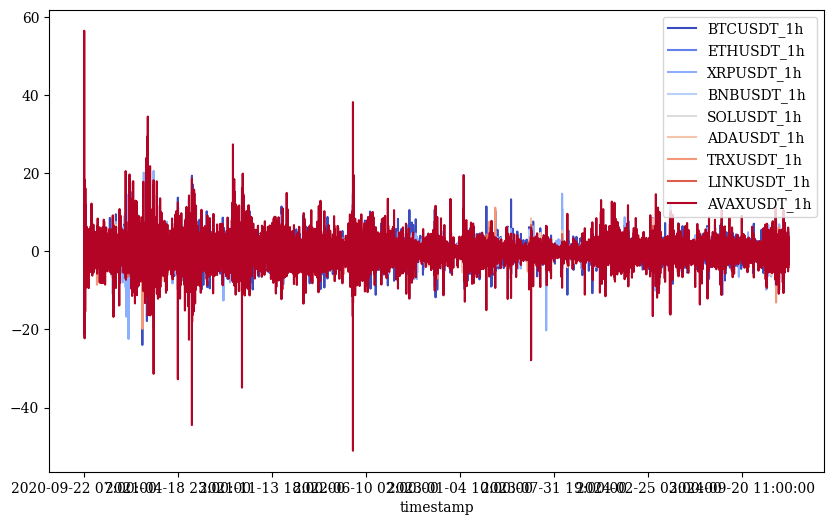

In [ ]:
rets = np.log(data / data.shift(1))
rets.dropna(inplace=True)
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
np.set_printoptions(suppress=True, precision=4)
fig, ax = plt.subplots(figsize=(10, 6))
(rets / rets.iloc[0]).plot(ax=ax, cmap='coolwarm')
ax.set_facecolor('#f7f7f7') 
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='gray', alpha=0.2)
ax.minorticks_on()
ax.tick_params(axis='x', rotation=45)
ax.set_title('Retornos de las Criptomonedas', fontsize=14)
ax.set_xlabel('Fecha y Hora')
ax.set_ylabel('Retornos')
plt.tight_layout()
plt.show()

In [10]:
dfs = {}
for sym in data:
    df, cols = add_lags(rets, sym, lags)
    mu, std = df[cols].mean(), df[cols].std() 
    df[cols] = (df[cols] - mu) / std
    dfs[sym] = df.dropna()

dfs[sym].head() 


,AVAXUSDT_1h,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
timestamp,,,,,,,,
2020-09-22 14:00:00,-0.066427,-4.305146,1.075231,3.490046,-8.733899,-6.646197,23.278113,0.408272
2020-09-22 15:00:00,-0.099217,-4.705600,-4.305086,1.075206,3.490003,-8.733797,-6.646107,23.277806
2020-09-22 16:00:00,0.044991,-7.026530,-4.705535,-4.305061,1.075195,3.489952,-8.733679,-6.646025
2020-09-22 17:00:00,-0.102231,3.180756,-7.026435,-4.705507,-4.305002,1.075175,3.489908,-8.733570
2020-09-22 18:00:00,-0.060018,-7.239839,3.180717,-7.026385,-4.705442,-4.304955,1.075162,3.489858


In [11]:
dfs[sym]['lag_1']

timestamp
2020-09-22 14:00:00   -4.305146
2020-09-22 15:00:00   -4.705600
2020-09-22 16:00:00   -7.026530
2020-09-22 17:00:00    3.180756
2020-09-22 18:00:00   -7.239839
                         ...   
2024-12-31 20:00:00    0.055249
2024-12-31 21:00:00   -0.259823
2024-12-31 22:00:00    0.114538
2024-12-31 23:00:00   -0.557517
2025-01-01 00:00:00    0.115267
Name: lag_1, Length: 37455, dtype: float64

Los retornos sí son estacionarios.

In [12]:
result = adfuller(dfs[sym]['lag_1']) 

print('ADF Statistic      :', result[0])
print('p-value            :', result[1])
print('Num lags used      :', result[2])
print('Num observations   :', result[3])
print('Critical values    :')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

ADF Statistic      : -27.545021025616403
p-value            : 0.0
Num lags used      : 45
Num observations   : 37409
Critical values    :
   1%: -3.4305
   5%: -2.8616
   10%: -2.5668


Y no están correlados.

In [16]:
dfs[sym].corr()

,AVAXUSDT_1h,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
AVAXUSDT_1h,1.000000,-0.037395,-0.026024,-0.005714,-0.012902,0.000605,0.007076,-0.016698
lag_1,-0.037395,1.000000,-0.037514,-0.026407,-0.004689,-0.012108,-0.002101,0.007031
lag_2,-0.026024,-0.037514,1.000000,-0.037404,-0.026635,-0.004879,-0.011345,-0.002088
lag_3,-0.005714,-0.026407,-0.037404,1.000000,-0.038185,-0.027248,-0.002654,-0.011307
lag_4,-0.012902,-0.004689,-0.026635,-0.038185,1.000000,-0.036548,-0.032493,-0.002746
lag_5,0.000605,-0.012108,-0.004879,-0.027248,-0.036548,1.000000,-0.040421,-0.032548
lag_6,0.007076,-0.002101,-0.011345,-0.002654,-0.032493,-0.040421,1.000000,-0.039874
lag_7,-0.016698,0.007031,-0.002088,-0.011307,-0.002746,-0.032548,-0.039874,1.000000


Predicciones sin train split, probablemente sobreajustadas.

In [17]:
from sklearn.metrics import accuracy_score

for sym in data:
    df = dfs[sym].dropna()
    reg = np.linalg.lstsq(df[cols], df[sym], rcond=-1)[0]
    pred = np.dot(df[cols], reg)
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "IN-SAMPLE")

OLS | BTCUSDT_1h | acc=0.5171
OLS | ETHUSDT_1h | acc=0.5131
OLS | XRPUSDT_1h | acc=0.5242
OLS | BNBUSDT_1h | acc=0.5028
OLS | SOLUSDT_1h | acc=0.5209
OLS | ADAUSDT_1h | acc=0.5214
OLS | TRXUSDT_1h | acc=0.4912
OLS | LINKUSDT_1h | acc=0.5101
OLS | AVAXUSDT_1h | acc=0.5107


In [18]:
for sym in data.columns:
    df = dfs[sym].dropna()
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(df[cols], df[sym])
    pred = model.predict(df[cols])
    acc = accuracy_score(np.sign(df[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "IN-SAMPLE")

MLP | BTCUSDT_1h | acc=0.5412
MLP | ETHUSDT_1h | acc=0.5193
MLP | XRPUSDT_1h | acc=0.5068
MLP | BNBUSDT_1h | acc=0.5119
MLP | SOLUSDT_1h | acc=0.5199
MLP | ADAUSDT_1h | acc=0.5138
MLP | TRXUSDT_1h | acc=0.4814
MLP | LINKUSDT_1h | acc=0.5171
MLP | AVAXUSDT_1h | acc=0.5052


Ahora entrenamos con unos datos y testeamos con otros (80% entrenamiento, 20% test).

In [19]:
split = int(len(dfs[sym]) * 0.8)
for sym in data.columns:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    reg = np.linalg.lstsq(train[cols], train[sym], rcond=-1)[0]
    test = df.iloc[split:]
    pred = np.dot(test[cols], reg)
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'OLS | {sym:10s} | acc={acc:.4f}')
    save_results('OLS', sym, acc, "OUT-SAMPLE")

OLS | BTCUSDT_1h | acc=0.5114
OLS | ETHUSDT_1h | acc=0.5123
OLS | XRPUSDT_1h | acc=0.5190
OLS | BNBUSDT_1h | acc=0.5017
OLS | SOLUSDT_1h | acc=0.5265
OLS | ADAUSDT_1h | acc=0.5188
OLS | TRXUSDT_1h | acc=0.4523
OLS | LINKUSDT_1h | acc=0.5042
OLS | AVAXUSDT_1h | acc=0.5131


In [ ]:
for sym in data.columns:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    model = MLPRegressor(hidden_layer_sizes=[512],
                        random_state=100,
                        max_iter=1000,
                        early_stopping=True,
                        validation_fraction=0.15,
                        shuffle=False)
    model.fit(train[cols], train[sym])
    test = df.iloc[split:]
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'MLP | {sym:10s} | acc={acc:.4f}')
    save_results('MLP', sym, acc, "OUT-SAMPLE")

MLP | BTCUSDT_1h | acc=0.4910
MLP | ETHUSDT_1h | acc=0.4844
MLP | XRPUSDT_1h | acc=0.4784
MLP | BNBUSDT_1h | acc=0.4969


C:\Users\raque\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


MLP | SOLUSDT_1h | acc=0.4744


In [ ]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

np.random.seed(100)
tf.random.set_seed(100)

def create_model(problem='regression'):
    model = Sequential()
    model.add(Dense(512, input_dim=len(cols),
                    activation='relu'))
    if problem == 'regression':
        model.add(Dense(1, activation='linear'))
        model.compile(loss='mse', optimizer='adam')
    else:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(loss='binary_crossentropy', optimizer='adam')
    return model


for sym in data.columns[:]:
    df = dfs[sym].dropna()
    train = df.iloc[:split]
    test = df.iloc[split:]
    model = create_model()
    model.fit(train[cols], train[sym], epochs=25, verbose=False)
    pred = model.predict(test[cols])
    acc = accuracy_score(np.sign(test[sym]), np.sign(pred))
    print(f'DNN | {sym:10s} | acc={acc:.4f}')
    save_results('DNN', sym, acc, "OUT-SAMPLE")

c:\Users\raque\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
DNN | BTCUSDTd   | acc=0.5056


Como podemos ver los resultados no son muy esperanzadores por lo que podemos asumir que los mercados son eficientes al menos en la forma debil. Es decir que no es posible sacar beneficios utilizando unicamente los valores pasados de las acciones. 